In [1]:
import os
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import os
import torch
import numpy as np
import pandas as pd
from natsort import natsorted
from torch.utils.data import Dataset, DataLoader as TorchDataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from torch.utils.data import random_split, DataLoader as TorchDataLoader
from torch.utils.data import Dataset
import torch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from models import Simple1DCNN
import matplotlib.pyplot as plt
import argparse
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

featidx = list(range(0, 8))  # use all features
transform = StandardScaler()

## Loading all files


In [2]:
# data_rock = {}
# data_paper = {}
# data_scissor = {}
# data_none = {}

# for sub in ['subject01', 'subject02', 'subject03', 'subject04', 'subject05', 'subject06', 'subject07', 'subject08', 'subject09', 'subject10']:

#     data_rock[sub] = []
#     data_paper[sub] = []
#     data_scissor[sub] = []
#     data_none[sub] = []
    
#     for ses in ['session01', 'session02', 'session03']:
        
#         data        = np.load(rf'C:\0_Working\PhD\Papers\SP7_RoShamBo\roshambo-main\data\{sub}_{ses}_emg.npy', allow_pickle=True)
#         annotation  = np.load(rf'C:\0_Working\PhD\Papers\SP7_RoShamBo\roshambo-main\data\{sub}_{ses}_ann.npy', allow_pickle=True)

#         data = torch.tensor(data, dtype=torch.float32)
#         data = transform.fit_transform(data)
#         data = torch.tensor(data, dtype=torch.float32)

#         for i in range(len(data)):
#             if annotation[i] == b'rock' or annotation[i] == 'rock':
#                 data_rock[sub].append(data[i,:])
#             elif annotation[i] == b'paper' or annotation[i] == 'paper':
#                 data_paper[sub].append(data[i,:])
#             elif annotation[i] == b'scissor' or annotation[i] == 'scissor':
#                 data_scissor[sub].append(data[i,:])
#             elif annotation[i] == b'none' or annotation[i] == 'none':
#                 data_none[sub].append(data[i,:])

# Rock, Paper, Scissor, dNone = [], [], [], []
# for sub in data_rock:
#     Rock += data_rock[sub]

# for sub in data_paper:
#     Paper += data_paper[sub]

# for sub in data_scissor:
#     Scissor += data_scissor[sub]

# for sub in data_none:    
#     dNone += data_none[sub]

# Rock = np.array(Rock)
# Paper = np.array(Paper)
# Scissor = np.array(Scissor)
# dNone = np.array(dNone)

# # setting abnormal data to the neighbouring data
# def set_abnormal_data(data, threshold=5):
#     mean = np.mean(data, axis=0)
#     std = np.std(data, axis=0)
#     for i in range(len(data)):
#         if np.any(np.abs(data[i] - mean) > threshold * std):
#             if i > 0:
#                 data[i] = data[i-1]
#             else:
#                 data[i] = data[i+1]
#     return data

# Scissor_outlier_free = set_abnormal_data(Scissor.copy())
# Rock_outlier_free = set_abnormal_data(Rock.copy())
# Paper_outlier_free = set_abnormal_data(Paper.copy())
# None_outlier_free = set_abnormal_data(dNone.copy())

# min_time = min(Rock_outlier_free.shape[0], Paper_outlier_free.shape[0], Scissor_outlier_free.shape[0], None_outlier_free.shape[0])
# Rock_final = Rock_outlier_free[:min_time]
# Paper_final = Paper_outlier_free[:min_time]
# Scissor_final = Scissor_outlier_free[:min_time]
# None_final = None_outlier_free[:min_time]

In [3]:
# print(f'Rock: {Rock_final.shape}, Paper: {Paper_final.shape}, Scissor: {Scissor_final.shape}, None: {None_final.shape}')

In [4]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split

class WindowedDataset(Dataset):
    def __init__(self, data_dict, window_size=64, hop_size=32):
        self.samples = []
        self.labels = []

        # label_map = {'rock': 0, 'paper': 1, 'scissor': 2, 'none': 3}
        label_map = {'rock': 1, 'paper': 1, 'scissor': 1, 'none': 0}
        
        for key, data in data_dict.items():
            label = label_map[key.lower()]
            for start in range(0, data.shape[0] - window_size + 1, hop_size):
                window = data[start:start + window_size]  # (window_size, 8)
                window = window.T  # (8, window_size)
                window = np.expand_dims(window, axis=0)  # (1, 8, window_size)
                self.samples.append(window)
                self.labels.append(label)

        self.samples = np.array(self.samples, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.int64)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return torch.tensor(self.samples[idx]), torch.tensor(self.labels[idx])

def create_dataloaders(data_dict, window_size=64, hop_size=32, batch_size=64, val_split=0.2):
    dataset = WindowedDataset(data_dict, window_size, hop_size)
    
    val_len = int(len(dataset) * val_split)
    train_len = len(dataset) - val_len
    train_dataset, val_dataset = random_split(dataset, [train_len, val_len])
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader


# rock_data_dict = {
#     'rock': Rock_final,
#     'none': None_final
# }

# paper_data_dict = {
#     'paper': Paper_final,
#     'none': None_final
# }

# scissor_data_dict = {
#     'scissor': Scissor_final,
#     'none': None_final
# }

batch_size = 32
# rock_tr_loader, rock_val_loader = create_dataloaders(rock_data_dict, window_size=400, hop_size=200, batch_size=batch_size, val_split=0.4)
# rock_dataloader, _ = create_dataloaders(rock_data_dict, window_size=400, hop_size=200, batch_size=batch_size, val_split=0.0)

# paper_tr_loader, paper_val_loader = create_dataloaders(paper_data_dict, window_size=400, hop_size=200, batch_size=batch_size, val_split=0.4)
# paper_dataloader, _ = create_dataloaders(paper_data_dict, window_size=400, hop_size=200, batch_size=batch_size, val_split=0.0)

# scissor_tr_loader, scissor_val_loader = create_dataloaders(scissor_data_dict, window_size=400, hop_size=200, batch_size=batch_size, val_split=0.4)
# scissor_dataloader, _ = create_dataloaders(scissor_data_dict, window_size=400, hop_size=200, batch_size=batch_size, val_split=0.0)

dir_loaders = 'dataloaders'
if not os.path.exists(dir_loaders):
    os.makedirs(dir_loaders)

torch.save(rock_data_dict, os.path.join(dir_loaders, 'rock_data_dict.pt'))
torch.save(paper_data_dict, os.path.join(dir_loaders, 'paper_data_dict.pt'))
torch.save(scissor_data_dict, os.path.join(dir_loaders, 'scissor_data_dict.pt'))
torch.save(rock_tr_loader, os.path.join(dir_loaders, 'rock_tr_loader.pt'))
torch.save(rock_val_loader, os.path.join(dir_loaders, 'rock_val_loader.pt'))
torch.save(paper_tr_loader, os.path.join(dir_loaders, 'paper_tr_loader.pt'))
torch.save(paper_val_loader, os.path.join(dir_loaders, 'paper_val_loader.pt'))
torch.save(scissor_tr_loader, os.path.join(dir_loaders, 'scissor_tr_loader.pt'))
torch.save(scissor_val_loader, os.path.join(dir_loaders, 'scissor_val_loader.pt'))
torch.save(rock_dataloader, os.path.join(dir_loaders, 'rock_dataloader.pt'))
torch.save(paper_dataloader, os.path.join(dir_loaders, 'paper_dataloader.pt'))
torch.save(scissor_dataloader, os.path.join(dir_loaders, 'scissor_dataloader.pt'))

In [8]:
# load all loaders
rock_tr_loader = torch.load(os.path.join(dir_loaders, 'rock_tr_loader.pt'), weights_only=False)
rock_val_loader = torch.load(os.path.join(dir_loaders, 'rock_val_loader.pt'), weights_only=False)
paper_tr_loader = torch.load(os.path.join(dir_loaders, 'paper_tr_loader.pt'), weights_only=False)
paper_val_loader = torch.load(os.path.join(dir_loaders, 'paper_val_loader.pt'), weights_only=False)
scissor_tr_loader = torch.load(os.path.join(dir_loaders, 'scissor_tr_loader.pt'), weights_only=False)
scissor_val_loader = torch.load(os.path.join(dir_loaders, 'scissor_val_loader.pt'), weights_only=False)
rock_dataloader = torch.load(os.path.join(dir_loaders, 'rock_dataloader.pt'), weights_only=False)
paper_dataloader = torch.load(os.path.join(dir_loaders, 'paper_dataloader.pt'), weights_only=False)
scissor_dataloader = torch.load(os.path.join(dir_loaders, 'scissor_dataloader.pt'), weights_only=False)

# check length of dataloaders
print(f'Rock train loader length: {len(rock_tr_loader)}, Rock validation loader length: {len(rock_val_loader)}')
print(f'Paper train loader length: {len(paper_tr_loader)}, Paper validation loader length: {len(paper_val_loader)}')
print(f'Scissor train loader length: {len(scissor_tr_loader)}, Scissor validation loader length: {len(scissor_val_loader)}')
print(f'Rock dataloader length: {len(rock_dataloader)}')
print(f'Paper dataloader length: {len(paper_dataloader)}')
print(f'Scissor dataloader length: {len(scissor_dataloader)}')

Rock train loader length: 12, Rock validation loader length: 8
Paper train loader length: 12, Paper validation loader length: 8
Scissor train loader length: 12, Scissor validation loader length: 8
Rock dataloader length: 19
Paper dataloader length: 19
Scissor dataloader length: 19


In [9]:
rock_labels = [label for _, label in rock_dataloader.dataset]
print(f'Rock labels: {rock_labels[:10]}')  

paper_labels = [label for _, label in paper_dataloader.dataset]
print(f'Paper labels: {paper_labels[:10]}')

scissor_labels = [label for _, label in scissor_dataloader.dataset]
print(f'Scissor labels: {scissor_labels[:10]}')

rock_class_counts = np.bincount(rock_labels)
rock_class_percentages = rock_class_counts / len(rock_labels) * 100
print(f'Rock class percentages: {rock_class_percentages}')

paper_class_counts = np.bincount(paper_labels)
paper_class_percentages = paper_class_counts / len(paper_labels) * 100
print(f'Paper class percentages: {paper_class_percentages}')

scissor_class_counts = np.bincount(scissor_labels)
scissor_class_percentages = scissor_class_counts / len(scissor_labels) * 100
print(f'Scissor class percentages: {scissor_class_percentages}')

Rock labels: [tensor(1), tensor(0), tensor(1), tensor(0), tensor(0), tensor(0), tensor(1), tensor(0), tensor(0), tensor(1)]
Paper labels: [tensor(1), tensor(1), tensor(0), tensor(0), tensor(0), tensor(0), tensor(0), tensor(1), tensor(1), tensor(1)]
Scissor labels: [tensor(0), tensor(1), tensor(1), tensor(0), tensor(1), tensor(0), tensor(0), tensor(0), tensor(1), tensor(1)]
Rock class percentages: [50. 50.]
Paper class percentages: [50. 50.]
Scissor class percentages: [50. 50.]


Original shape: torch.Size([32, 1, 8, 400]), Modified shape: torch.Size([32, 1, 8, 400])


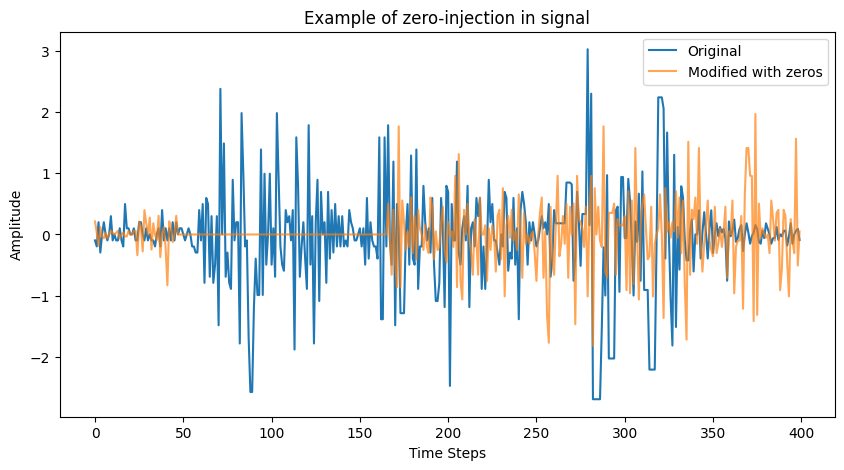

In [17]:
from torch.utils.data import TensorDataset

def add_zeros_at_random_positions(dataloader, min_zero_length=75, max_zero_length=125):
  """
  Create a new dataloader where random segments of time series data are replaced with zeros.
  
  Args:
    dataloader: Original dataloader containing the data
    min_zero_length: Minimum length of zero segment (default: 75)
    max_zero_length: Maximum length of zero segment (default: 125)
  
  Returns:
    A new dataloader with modified data
  """
  all_modified_data = []
  all_labels = []
  
  # Process each batch from the original dataloader
  for data, labels in dataloader:
    batch_size, channels, sensors, timesteps = data.shape
    
    # Process each sample in the batch
    for i in range(batch_size):
      sample = data[i].clone()  # Shape: [channels, sensors, timesteps]
      
      # Choose random length for the zero segment
      zero_length = torch.randint(min_zero_length, max_zero_length + 1, (1,)).item()
      
      # Choose random position to insert zeros (ensure it fits within the time series)
      max_start_pos = timesteps - zero_length
      if max_start_pos <= 0:  # Handle case where zero_length > timesteps
        start_pos = 0
        zero_length = timesteps  # Just zero out the whole sequence
      else:
        start_pos = torch.randint(0, max_start_pos, (1,)).item()
      
      # Set the segment to zeros
      sample[:, :, start_pos:start_pos + zero_length] = 0.0
      
      all_modified_data.append(sample)
      all_labels.append(labels[i])
  
  # Convert lists to tensors
  all_modified_data = torch.stack(all_modified_data)
  all_labels = torch.stack(all_labels)
  
  # Create dataset and dataloader
  modified_dataset = TensorDataset(all_modified_data, all_labels)
  
  # Create new dataloader with same batch size
  modified_dataloader = DataLoader(
    modified_dataset,
    batch_size=dataloader.batch_size,
    shuffle=True
  )
  
  return modified_dataloader

# Create modified dataloaders with zeros injected
rock_dataloader_zeros = add_zeros_at_random_positions(rock_dataloader)
paper_dataloader_zeros = add_zeros_at_random_positions(paper_dataloader)
scissor_dataloader_zeros = add_zeros_at_random_positions(scissor_dataloader)

torch.save(rock_dataloader_zeros, os.path.join(dir_loaders, 'rock_dataloader_zeros.pt'))
torch.save(paper_dataloader_zeros, os.path.join(dir_loaders, 'paper_dataloader_zeros.pt'))
torch.save(scissor_dataloader_zeros, os.path.join(dir_loaders, 'scissor_dataloader_zeros.pt'))

# Verify the modification
original_sample, _ = next(iter(rock_dataloader))
modified_sample, _ = next(iter(rock_dataloader_zeros))
print(f"Original shape: {original_sample.shape}, Modified shape: {modified_sample.shape}")

# Plot an example to visualize the zero regions
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
# Plot original and modified signal for comparison (sensor 4, first sample)
plt.plot(original_sample[0, 0, 2, :].numpy(), label='Original')
plt.plot(modified_sample[0, 0, 2, :].numpy(), label='Modified with zeros', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')
plt.legend()
plt.title('Example of zero-injection in signal')
plt.show()

Sample shape: torch.Size([32, 1, 8, 400]), Label shape: torch.Size([32])


/var/folders/5j/ht2fz5f533v784zdwn2rzcjm0000gn/T/ipykernel_85052/2617942397.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


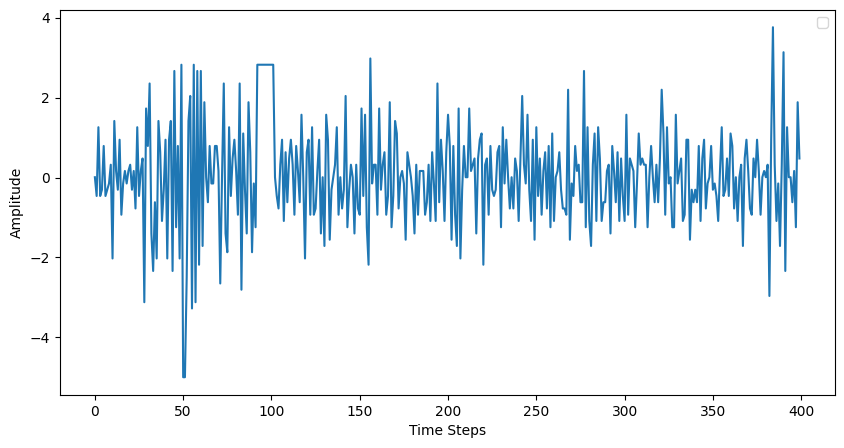

Sample shape: torch.Size([32, 1, 8, 400]), Label shape: torch.Size([32])


/var/folders/5j/ht2fz5f533v784zdwn2rzcjm0000gn/T/ipykernel_85052/2617942397.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


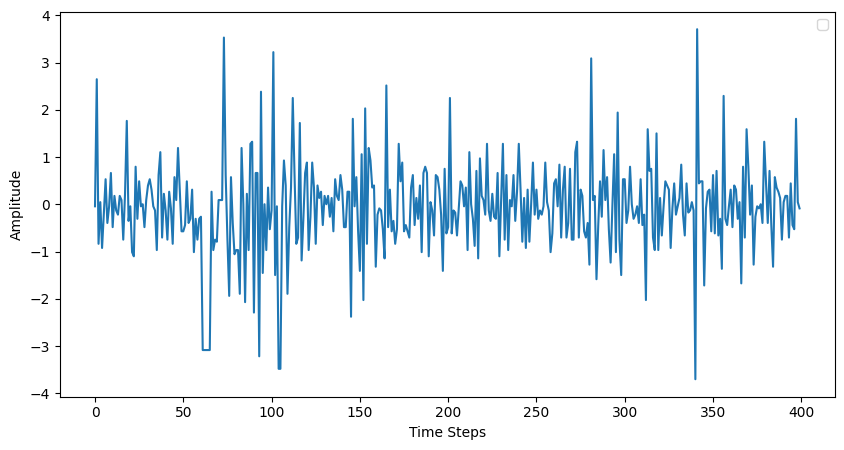

Sample shape: torch.Size([32, 1, 8, 400]), Label shape: torch.Size([32])


/var/folders/5j/ht2fz5f533v784zdwn2rzcjm0000gn/T/ipykernel_85052/2617942397.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


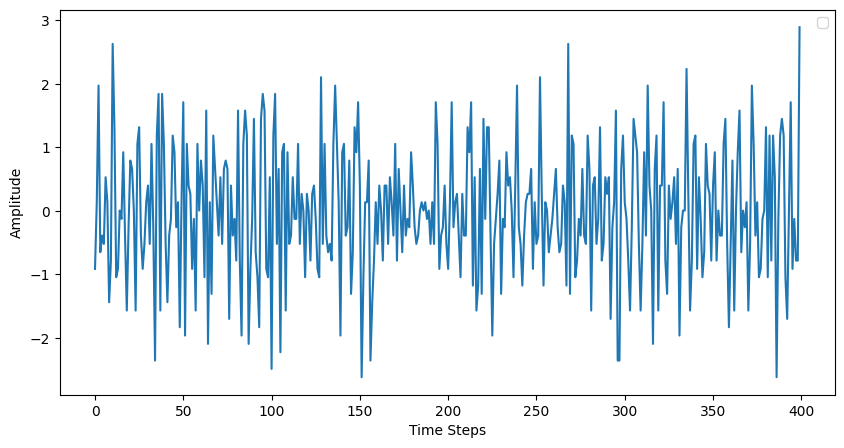

In [14]:
sample = next(iter(rock_dataloader))
print(f'Sample shape: {sample[0].shape}, Label shape: {sample[1].shape}')
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt.plot(sample[0][0, 0, 4, :].numpy())
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

sample = next(iter(paper_dataloader))
print(f'Sample shape: {sample[0].shape}, Label shape: {sample[1].shape}')
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt.plot(sample[0][0, 0, 4, :].numpy())
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

sample = next(iter(scissor_dataloader))
print(f'Sample shape: {sample[0].shape}, Label shape: {sample[1].shape}')
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt.plot(sample[0][0, 0, 4, :].numpy())
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')
plt.legend()
plt.show()



## Model (Sensor Reconstruction)


In [18]:
import os
import torch
import numpy as np
import pandas as pd
from natsort import natsorted
from torch.utils.data import Dataset, DataLoader as TorchDataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm


def normalize(tensor):
    min_val = tensor.amin(dim=-1, keepdim=True)
    max_val = tensor.amax(dim=-1, keepdim=True)
    return (tensor - min_val) / (max_val - min_val + 1e-8)


class SpectralLoss(nn.Module):
    def __init__(self):
        super(SpectralLoss, self).__init__()

    def forward(self, x, y):
        # Apply FFT along the time dimension (last dim assumed to be time)
        x_fft = torch.fft.rfft(x, dim=-1)
        y_fft = torch.fft.rfft(y, dim=-1)

        # Compare magnitude spectrum
        x_mag = torch.abs(x_fft)
        y_mag = torch.abs(y_fft)

        return F.mse_loss(x_mag, y_mag)

class CombinedLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=1.0):
        super(CombinedLoss, self).__init__()
        self.mse = nn.MSELoss()
        self.spectral = SpectralLoss()
        self.alpha = alpha  # weight for MSE
        self.beta = beta    # weight for spectral

    def forward(self, recon, target):
        mse_loss = self.mse(recon, target)
        spectral_loss = self.spectral(recon, target)
        return self.alpha * mse_loss + self.beta * spectral_loss


class Encoder_1(nn.Module):
    def __init__(self, dropout_rate=0.2):
        super(Encoder_1, self).__init__()

        self.dropout_rate = dropout_rate
        self.conv1 = nn.Conv2d(1, 128, kernel_size=(1, 5), stride=(1,2) ,padding=(0, 0)) 
        self.batchnorm1 = nn.BatchNorm2d(128)  
        self.dropout1 = nn.Dropout(self.dropout_rate)
        self.conv2 = nn.Conv2d(128, 256, kernel_size=(1, 3), stride=(1,1) ,padding=(0, 0))   
        self.batchnorm2 = nn.BatchNorm2d(256)
        self.dropout2 = nn.Dropout(self.dropout_rate)
        self.conv3 = nn.Conv2d(256, 512, kernel_size=(1, 3), stride=(1,2) ,padding=(0, 0))   
        self.batchnorm3 = nn.BatchNorm2d(512)
        self.dropout3 = nn.Dropout(self.dropout_rate)
        self.conv4 = nn.Conv2d(512, 1, kernel_size=(1, 3), stride=(1,1) ,padding=(0, 0))   
        self.leaky_relu = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x):
        # print(x.shape)
        x = F.relu(self.conv1(x))
        x = self.batchnorm1(x)
        x = self.dropout1(x)
        # print(x.shape)
        x = self.leaky_relu(self.conv2(x))
        x = self.batchnorm2(x)
        x = self.dropout2(x)
        # print(x.shape)
        x = F.elu(self.conv3(x)); 
        x = self.batchnorm3(x)
        x = self.dropout3(x)
        # print(x.shape)
        x = self.conv4(x); 
        # print(x.shape)
        return x 

class Decoder_1(nn.Module):
    def __init__(self, dropout_rate=0.2):
        self.dropout_rate = dropout_rate

        super(Decoder_1, self).__init__()
        self.deconv1 = nn.ConvTranspose2d(1, 512, kernel_size=(1, 3), stride=(1, 1))   
        self.deconv1_bn = nn.BatchNorm2d(512)
        self.deconv1_dp = nn.Dropout(self.dropout_rate)            
        self.deconv2 = nn.ConvTranspose2d(512, 256, kernel_size=(1, 3), stride=(1, 2), output_padding=(0, 1))  # W: 34 → 69
        self.deconv2_bn = nn.BatchNorm2d(256)
        self.deconv2_dp = nn.Dropout(self.dropout_rate)
        self.deconv3 = nn.ConvTranspose2d(256, 128, kernel_size=(1, 3), stride=(1, 1), output_padding=(0, 0))   # W: 69 → 141
        self.deconv3_bn = nn.BatchNorm2d(128)
        self.deconv3_dp = nn.Dropout(self.dropout_rate)
        self.deconv4 = nn.ConvTranspose2d(128, 1, kernel_size=(1, 5), stride=(1, 2), output_padding=(0, 1))    # W: 141 → 300

    def forward(self, x):
        x = F.relu(self.deconv1(x))         
        x = self.deconv1_bn(x)
        x = self.deconv1_dp(x)
        # print("deconv1:", x.shape)
        x = F.softplus(self.deconv2(x))     # (B, 64, 1, 69)
        x = self.deconv2_bn(x)
        x = self.deconv2_dp(x)
        # print("deconv2:", x.shape)
        x = F.elu(self.deconv3(x))          # (B, 32, 1, 141)
        x = self.deconv3_bn(x)
        x = self.deconv3_dp(x)
        # print("deconv3:", x.shape)
        # x = F.tanh(self.deconv4(x))         # (B, 5, 1, 300)
        x = (self.deconv4(x))         # (B, 5, 1, 300)
        # print("deconv4:", x.shape)
        return x

        
class Autoencoder_type1(nn.Module):
    def __init__(self, dropout_rate=0.2):
        super(Autoencoder_type1, self).__init__()
        self.dropout_rate = dropout_rate
        self.encoder = Encoder_1(self.dropout_rate)
        self.decoder = Decoder_1(self.dropout_rate)

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent


if __name__ == "__main__":
    x = torch.randn(133, 1, 8, 400)# Example input (B=1, C=1, H=1, W=200)
    model1 = Autoencoder_type1(dropout_rate=0.2)
    reconstructed, latent = model1(x)
    print("Input shape:", x.shape)
    print("Reconstructed shape:", reconstructed.shape) 
    print("Latent shape:", latent.shape) 

Input shape: torch.Size([133, 1, 8, 400])
Reconstructed shape: torch.Size([133, 1, 8, 400])
Latent shape: torch.Size([133, 1, 8, 95])


## Train the autoencoder


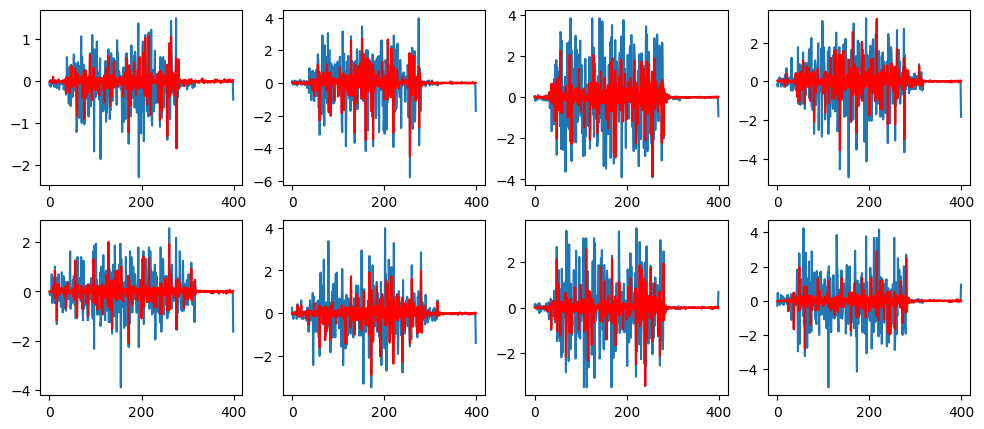

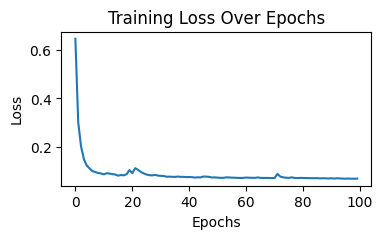

Epoch 100 Avg Loss: 0.0711


In [21]:
from IPython.display import clear_output

class_name = "paper"

data_loaders_autoencoder = paper_dataloader_zeros


data_tr = data_loaders_autoencoder.dataset[:int(len(data_loaders_autoencoder) * 0.8)]
data_val = data_loaders_autoencoder.dataset[int(len(data_loaders_autoencoder) * 0.8):]
data_loader_tr = DataLoader(data_tr, batch_size=32, shuffle=True)
data_loader_val = DataLoader(data_val, batch_size=32, shuffle=False)

model = Autoencoder_type1(dropout_rate=0.3).to(torch.device("mps"))
autoencoder_save_path = f"param_autoencoder_{class_name}_v2.pth" 

criterion = nn.HuberLoss(delta=0.25)  # delta is the threshold for switching between MSE and MAE
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)

model.train()
epoch_loss_best = 1.0

loss_log = []
for epoch in range(100):
    epoch_loss = 0.0
    loop = tqdm(data_loaders_autoencoder, desc=f"Epoch {epoch+1}", leave=False)

    for batch,_ in loop:
        
        input = torch.tensor(batch.to(torch.device("mps")), dtype=torch.float32)
        output, _ = model(input)  
        loss = criterion(output, input)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())
        
    avg_loss = epoch_loss / len(data_loaders_autoencoder)

    loss_log.append(avg_loss)

    if (epoch + 1) % 1 == 0:
        with torch.no_grad():
            sample_input = input[0].squeeze(0).detach().cpu().numpy()     # (channels, time)
            sample_output = output[0].squeeze(0).detach().cpu().numpy()   # (channels, time)

            clear_output(wait=True)  # <-- this clears the previous plots

            fig, ax = plt.subplots(2, 4, figsize=(12, 5))
            ax[0,0].plot(sample_input[0])
            ax[0,0].plot(sample_output[0], '-' , color='red')
            ax[0,1].plot(sample_input[1])
            ax[0,1].plot(sample_output[1], '-', color='red')
            ax[0,2].plot(sample_input[2])
            ax[0,2].plot(sample_output[2], '-', color='red')
            ax[0,3].plot(sample_input[3])
            ax[0,3].plot(sample_output[3], '-', color='red')
            ax[1,0].plot(sample_input[4])
            ax[1,0].plot(sample_output[4], '-', color='red')
            ax[1,1].plot(sample_input[5])
            ax[1,1].plot(sample_output[5], '-', color='red')
            ax[1,2].plot(sample_input[6])
            ax[1,2].plot(sample_output[6], '-', color='red')   
            ax[1,3].plot(sample_input[7])
            ax[1,3].plot(sample_output[7], '-', color='red')
            plt.show()            

            fig, ax = plt.subplots(figsize=(4, 2))
            ax.plot(loss_log)
            ax.set_title('Training Loss Over Epochs')   
            ax.set_xlabel('Epochs')
            ax.set_ylabel('Loss')
            plt.show()

    if avg_loss < epoch_loss_best:
        epoch_loss_best = avg_loss
        torch.save(model.state_dict(), autoencoder_save_path)
        print(f"Model saved at epoch {epoch+1} with loss: {avg_loss:.4f}")
    else:
        print(f"Epoch {epoch+1} Avg Loss: {avg_loss:.4f}")


## Testing the Reconstruction


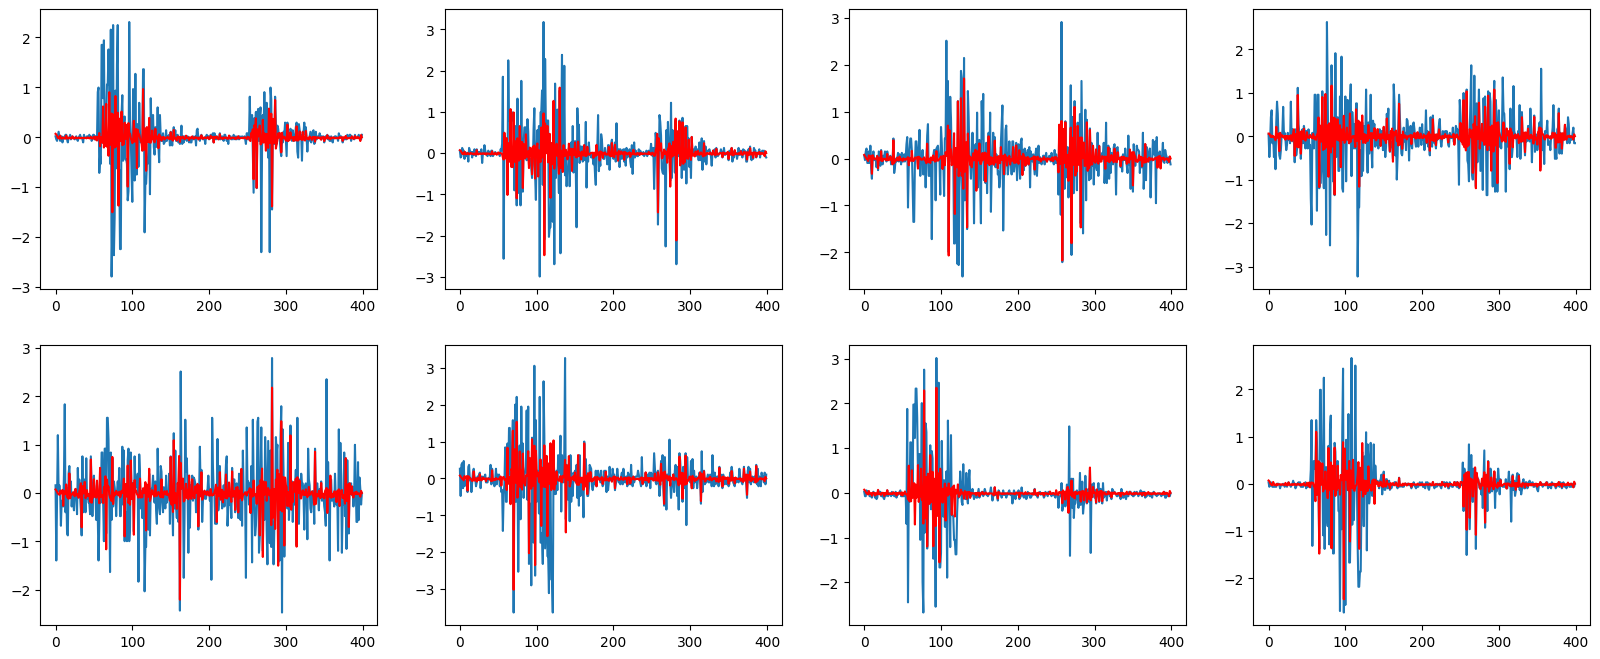

In [11]:
class_name = "paper"

data_loaders_autoencoder = paper_tr_loader

autoencoder_save_path = f"param_autoencoder_{class_name}_v1.pth" 
model = Autoencoder_type1(dropout_rate=0.2).to(torch.device("mps"))
model.load_state_dict(torch.load(autoencoder_save_path))

model.eval()
with torch.no_grad():
    for batch in data_loaders_autoencoder:
        inputs, label = batch
        batch_reshaped = inputs.to(torch.device("mps"))
        output, _ = model(batch_reshaped)
        sample_input = inputs[0].squeeze(0).detach().cpu().numpy()     # (channels, time)
        sample_output = output[0].squeeze(0).detach().cpu().numpy()
        fig, ax = plt.subplots(2, 4, figsize=(20, 8))
        ax[0,0].plot(sample_input[0])
        ax[0,0].plot(sample_output[0], alpha=1.0 , color='red')
        ax[0,1].plot(sample_input[1])
        ax[0,1].plot(sample_output[1], alpha=1.0 , color='red')
        ax[0,2].plot(sample_input[2])
        ax[0,2].plot(sample_output[2], alpha=1.0 , color='red')
        ax[0,3].plot(sample_input[3])
        ax[0,3].plot(sample_output[3], alpha=1.0 , color='red')
        ax[1,0].plot(sample_input[4])
        ax[1,0].plot(sample_output[4], alpha=1.0 , color='red')
        ax[1,1].plot(sample_input[5])
        ax[1,1].plot(sample_output[5], alpha=1.0 , color='red')
        ax[1,2].plot(sample_input[6])
        ax[1,2].plot(sample_output[6], alpha=1.0 , color='red')   
        ax[1,3].plot(sample_input[7])
        ax[1,3].plot(sample_output[7], alpha=1.0 , color='red')
        plt.show()  
        break                

## Classification Model


In [23]:
from models import Simple1DCNN

featidx = list(range(0, 8))  # use all features
model_class = Simple1DCNN(num_sensors=len(featidx), num_classes=2).to('mps')
dummy_input = torch.randn(batch_size, len(featidx), 95).to('mps')  # Example input
print("Input shape:", dummy_input.shape)  # Should be (B, num_sensors, W)
output = model_class(dummy_input)
print("Output shape:", output.shape)  # Should be (B, num_classes)


Input shape: torch.Size([32, 8, 95])
Output shape: torch.Size([32, 2])


## Training the Classifier


In [25]:
from IPython.display import clear_output
from tqdm import tqdm
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


train_loader = paper_tr_loader
val_loader = paper_val_loader

model = Autoencoder_type1(dropout_rate=0.2).to(torch.device("mps"))
model.load_state_dict(torch.load(autoencoder_save_path))
model.eval()

calssifier_save_path = f"param_classifier_{class_name}_v2.pth" 

featidx = list(range(0, 8)) 
model_class = Simple1DCNN(num_sensors=len(featidx), num_classes=2).to('mps')
# model_class.load_state_dict(torch.load(calssifier_save_path))

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model_class.parameters(),
    lr=2e-4,
    weight_decay=1e-4,
)

# Training setup
num_epochs = 100
best_val_loss = 0
loss_log = []
best_val_acc = 0.0

train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_f1s, val_f1s = [], []

for epoch in range(num_epochs):
    model_class.train()
    train_loss, train_total = 0, 0
    train_correct = 0
    all_train_preds, all_train_targets = [], []
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{batch_size}")

    for batch in pbar:
        X, y = batch
        X, y = (
            X.to('mps'),
            y.to('mps'),
        )
        batch_reshaped = X.to(torch.device("mps"))        

        with torch.no_grad():
            _, latent_1 = model(batch_reshaped)

        input = latent_1.squeeze(1).to(torch.device("mps"))

        outputs = model_class(input)

        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_total += y.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        train_correct += (predicted == y).sum().item()

        # Store predictions and targets for F1 score
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_targets.extend(y.cpu().numpy())

        # Calculate metrics
        train_acc = train_correct / train_total
        train_f1 = f1_score(all_train_targets, all_train_preds, average="weighted")

        # Update progress bar
        pbar.set_postfix(
            {
                "loss": f"{train_loss/train_total:.4f}",
                "acc": f"{train_acc:.4f}",
                "f1": f"{train_f1:.4f}",
            }
        )

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    train_f1 = f1_score(all_train_targets, all_train_preds, average="weighted")

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)

    # Validation
    model_class.eval()
    val_loss, val_total = 0, 0
    val_correct = 0
    all_val_preds, all_val_targets = [], []


    with torch.no_grad():
        for batch in val_loader:
            X_v, y_y = batch
            X_v, y_y = (
                X_v.to('mps'),
                y_y.to('mps'),
            )
            val_batch_reshaped = X_v.to(torch.device("mps"))       

            with torch.no_grad():
                _, latent_ = model(val_batch_reshaped)

            input_vl = latent_.squeeze(1).to(torch.device("mps"))

            outputs = model_class(input_vl)
            loss = criterion(outputs, y_y)

            val_loss += loss.item()
            val_total += y_y.size(0)

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == y_y).sum().item()

            # Store predictions and targets for F1 score
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_targets.extend(y_y.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_f1 = f1_score(all_val_targets, all_val_preds, average="weighted")

    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}, "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_class.state_dict(), calssifier_save_path)
        print(f"Model saved at epoch {epoch+1} with val acc: {val_acc:.4f}")

Epoch 1/32: 100%|██████████| 12/12 [00:00<00:00, 23.09it/s, loss=0.0224, acc=0.5590, f1=0.5280]


Epoch [1/100], Train Loss: 0.6657, Train Acc: 0.5590, Train F1: 0.5280, Val Loss: 0.6760, Val Acc: 0.5127, Val F1: 0.3973
Model saved at epoch 1 with val acc: 0.5127


Epoch 2/32: 100%|██████████| 12/12 [00:00<00:00, 24.12it/s, loss=0.0218, acc=0.5421, f1=0.4096]


Epoch [2/100], Train Loss: 0.6469, Train Acc: 0.5421, Train F1: 0.4096, Val Loss: 0.6668, Val Acc: 0.4661, Val F1: 0.2964


Epoch 3/32: 100%|██████████| 12/12 [00:00<00:00, 23.81it/s, loss=0.0224, acc=0.5253, f1=0.3648]


...

Epoch [98/100], Train Loss: 0.1557, Train Acc: 0.9522, Train F1: 0.9522, Val Loss: 0.3702, Val Acc: 0.9195, Val F1: 0.9187


Epoch 99/32: 100%|██████████| 12/12 [00:00<00:00, 23.03it/s, loss=0.0033, acc=0.9663, f1=0.9663]


Epoch [99/100], Train Loss: 0.0990, Train Acc: 0.9663, Train F1: 0.9663, Val Loss: 0.2775, Val Acc: 0.9661, Val F1: 0.9661


Epoch 100/32: 100%|██████████| 12/12 [00:00<00:00, 22.53it/s, loss=0.0041, acc=0.9607, f1=0.9606]


Epoch [100/100], Train Loss: 0.1227, Train Acc: 0.9607, Train F1: 0.9606, Val Loss: 0.2839, Val Acc: 0.9619, Val F1: 0.9619


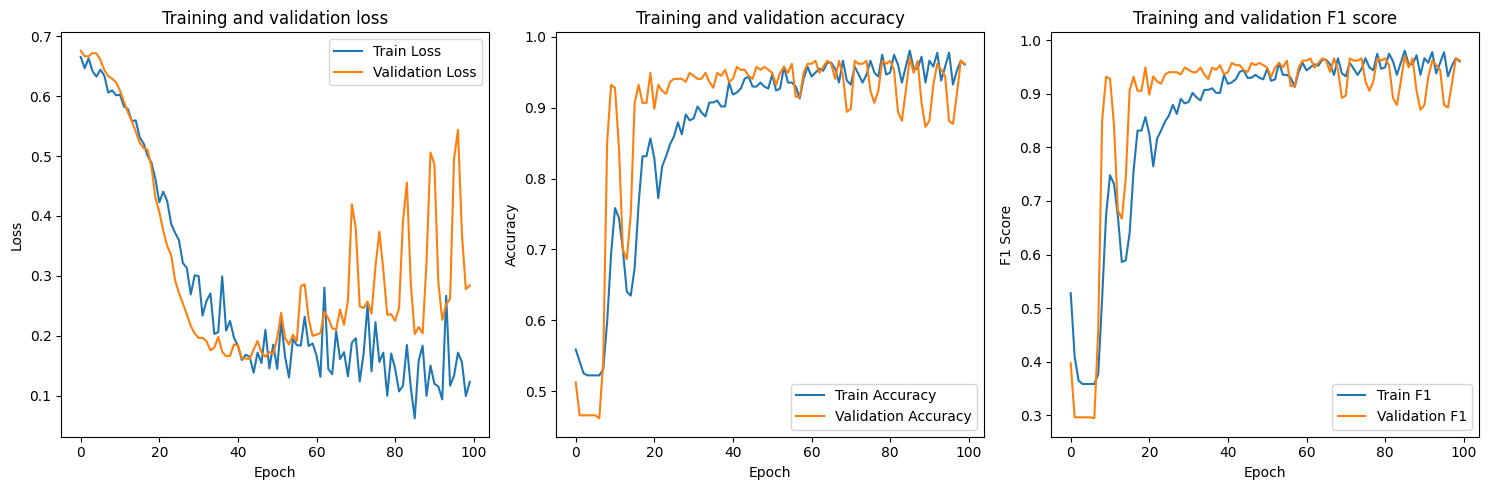

Validation Accuracy: 0.970, Validation F1: 0.970, Validation Loss: 0.203


In [26]:
# Plotting
plt.figure(figsize=(15, 5))

# Loss plot
plt.subplot(1, 3, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and validation loss")

# Accuracy plot
plt.subplot(1, 3, 2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and validation accuracy")

# F1 score plot
plt.subplot(1, 3, 3)
plt.plot(train_f1s, label="Train F1")
plt.plot(val_f1s, label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.legend()
plt.title("Training and validation F1 score")

plt.tight_layout()
plt.savefig("plots/training_plot.png")
plt.show()

print(f'Validation Accuracy: {val_accs[val_accs.index(max(val_accs))]:.3f}, Validation F1: {val_f1s[val_accs.index(max(val_accs))]:.3f}, Validation Loss: {val_losses[val_accs.index(max(val_accs))]:.3f}')

## Test the classification


In [29]:
from IPython.display import clear_output
from tqdm import tqdm
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from models import Simple1DCNN

train_loader = paper_tr_loader
val_loader = paper_val_loader

model = Autoencoder_type1(dropout_rate=0.2).to(torch.device("mps"))
model.load_state_dict(torch.load(autoencoder_save_path))
model.eval()

calssifier_save_path = f"param_classifier_{class_name}_v2.pth" 

featidx = list(range(0, 8))  # use all features
model_class = Simple1DCNN(num_sensors=len(featidx), num_classes=2).to(torch.device("mps"))
model_class.load_state_dict(torch.load(calssifier_save_path))

criterion = nn.CrossEntropyLoss()

val_losses = [], []
val_accs = [], []
val_f1s = [], []

# Validation
model_class.eval()
val_loss, val_total = 0, 0
val_correct = 0
all_val_preds, all_val_targets = [], []


with torch.no_grad():
    for batch in val_loader:
        X, y = batch
        X, y = (
            X.to('mps'),
            y.to('mps'),
        )
        val_batch_reshaped = X.to(torch.device("mps"))        

        with torch.no_grad():
            _, latent_ = model(val_batch_reshaped)

        input_vl = latent_.squeeze(1).to(torch.device("mps"))
        outputs = model_class(input_vl)
        loss = criterion(outputs, y)

        val_loss += loss.item()
        val_total += y.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        val_correct += (predicted == y).sum().item()

        # Store predictions and targets for F1 score
        all_val_preds.extend(predicted.cpu().numpy())
        all_val_targets.extend(y.cpu().numpy())

val_loss /= len(val_loader)
val_acc = val_correct / val_total
val_f1 = f1_score(all_val_targets, all_val_preds, average="weighted")

# print the results
print(
    f"Validation Loss: {val_loss:.4f}, Validation Acc: {val_acc:.4f}, Validation F1: {val_f1:.4f}"
)


Validation Loss: 0.2026, Validation Acc: 0.9703, Validation F1: 0.9703


## Sensor ablation impact on the classification accuracy


In [31]:
from sklearn.metrics import f1_score
import numpy as np

# Store performance metrics
sensor_accs = []
sensor_f1s = []

# Loop through each sensor index
for sensor_idx in range(8):
    print(f"\nAblating Sensor {sensor_idx}...")
    
    model_class.eval()
    val_loss, val_total = 0, 0
    val_correct = 0
    all_val_preds, all_val_targets = [], []

    with torch.no_grad():
        for batch in val_loader:
            X, y = batch
            X, y = X.to('mps'), y.to('mps')

            # Ablate the specific sensor (set its values to 0)
            X_ablate = X.clone()
            X_ablate[:, :, sensor_idx, :] = 0.0

            # Encode input
            _, latent_ = model(X_ablate)
            input_vl = latent_.squeeze(1)

            outputs = model_class(input_vl)
            _, predicted = torch.max(outputs.data, 1)

            val_correct += (predicted == y).sum().item()
            val_total += y.size(0)

            all_val_preds.extend(predicted.cpu().numpy())
            all_val_targets.extend(y.cpu().numpy())

    acc = val_correct / val_total
    f1 = f1_score(all_val_targets, all_val_preds, average='weighted')

    sensor_accs.append(acc)
    sensor_f1s.append(f1)

    print(f"Ablated Sensor {sensor_idx} - Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")



Ablating Sensor 0...
Ablated Sensor 0 - Accuracy: 0.9576, F1 Score: 0.9575

Ablating Sensor 1...
Ablated Sensor 1 - Accuracy: 0.7500, F1 Score: 0.7279

Ablating Sensor 2...
Ablated Sensor 2 - Accuracy: 0.8644, F1 Score: 0.8613

Ablating Sensor 3...
Ablated Sensor 3 - Accuracy: 0.9534, F1 Score: 0.9534

Ablating Sensor 4...
Ablated Sensor 4 - Accuracy: 0.9110, F1 Score: 0.9111

Ablating Sensor 5...
Ablated Sensor 5 - Accuracy: 0.9576, F1 Score: 0.9576

Ablating Sensor 6...
Ablated Sensor 6 - Accuracy: 0.9534, F1 Score: 0.9533

Ablating Sensor 7...
Ablated Sensor 7 - Accuracy: 0.9153, F1 Score: 0.9145


In [33]:
import itertools
import torch
from sklearn.metrics import f1_score

acc_threshold = val_acc * 0.95

selected_sensors = []
best_acc = 0
remaining_sensors = list(range(8))

while best_acc < acc_threshold and remaining_sensors:
    best_sensor = None
    best_sensor_acc = 0
    best_sensor_f1 = 0

    for s in remaining_sensors:
        test_sensors = selected_sensors + [s]
        
        model_class.eval()
        val_correct, val_total = 0, 0
        all_val_preds, all_val_targets = [], []

        with torch.no_grad():
            for batch in val_loader:
                X, y = batch
                X, y = X.to('mps'), y.to('mps')

                # Ablate all sensors not in test_sensors
                X_ablate = X.clone()
                for i in range(8):
                    if i not in test_sensors:
                        X_ablate[:, :, i, :] = 0.0

                # Encode and predict
                _, latent_ = model(X_ablate)
                input_vl = latent_.squeeze(1)
                outputs = model_class(input_vl)
                _, predicted = torch.max(outputs.data, 1)

                val_correct += (predicted == y).sum().item()
                val_total += y.size(0)
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_targets.extend(y.cpu().numpy())

        acc = val_correct / val_total
        f1 = f1_score(all_val_targets, all_val_preds, average='weighted')

        if acc > best_sensor_acc:
            best_sensor_acc = acc
            best_sensor = s
            best_sensor_f1 = f1

    if best_sensor is not None:
        selected_sensors.append(best_sensor)
        remaining_sensors.remove(best_sensor)
        best_acc = best_sensor_acc
        print(f"Selected sensor {best_sensor}, Accuracy: {best_sensor_acc:.4f}, F1: {best_sensor_f1:.4f}")
    else:
        break

print(f"\nMinimal subset of sensors reaching ≥{acc_threshold:.2f}% accuracy: {selected_sensors}")


Selected sensor 1, Accuracy: 0.8983, F1: 0.8967
Selected sensor 7, Accuracy: 0.9534, F1: 0.9533

Minimal subset of sensors reaching ≥0.92% accuracy: [1, 7]


In [35]:

# Track selected sensors
selected_sensors = []
best_acc = 0
remaining_sensors = list(range(8))  # Assuming 8 sensors

print("\nStarting Greedy Forward Sensor Selection...\n")

while best_acc < acc_threshold and remaining_sensors:
    best_sensor = None
    best_sensor_acc = 0
    best_sensor_f1 = 0

    for s in remaining_sensors:
        test_sensors = selected_sensors + [s]

        model_class.eval()
        val_correct, val_total = 0, 0
        all_val_preds, all_val_targets = [], []

        with torch.no_grad():
            for batch in val_loader:
                X, y = batch
                X, y = X.to('mps'), y.to('mps')

                # Zero out sensors not in test_sensors
                X_ablate = X.clone()
                for i in range(8):
                    if i not in test_sensors:
                        X_ablate[:, :, i, :] = 0.0

                # Forward pass
                _, latent_ = model(X_ablate)
                input_vl = latent_.squeeze(1)

                outputs = model_class(input_vl)
                _, predicted = torch.max(outputs.data, 1)

                val_correct += (predicted == y).sum().item()
                val_total += y.size(0)
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_targets.extend(y.cpu().numpy())

        acc = val_correct / val_total
        f1 = f1_score(all_val_targets, all_val_preds, average='weighted')

        print(f"Trying sensors {test_sensors} --> Accuracy: {acc:.4f}, F1: {f1:.4f}")

        if acc > best_sensor_acc:
            best_sensor_acc = acc
            best_sensor = s
            best_sensor_f1 = f1

    if best_sensor is not None:
        selected_sensors.append(best_sensor)
        remaining_sensors.remove(best_sensor)
        best_acc = best_sensor_acc
        print(f"✅ Added sensor {best_sensor}. Subset: {selected_sensors} -- Accuracy: {best_acc:.4f}, F1: {best_sensor_f1:.4f}\n")
    else:
        print("No more improvement possible.")
        break

print(f"🎯 Final minimal sensor subset with ≥{acc_threshold:.2f}% accuracy: {selected_sensors}")



Starting Greedy Forward Sensor Selection...

Trying sensors [0] --> Accuracy: 0.5339, F1: 0.3717
Trying sensors [1] --> Accuracy: 0.8983, F1: 0.8967
Trying sensors [2] --> Accuracy: 0.6271, F1: 0.5511
Trying sensors [3] --> Accuracy: 0.5339, F1: 0.3717
Trying sensors [4] --> Accuracy: 0.5381, F1: 0.3811
Trying sensors [5] --> Accuracy: 0.5466, F1: 0.3995
Trying sensors [6] --> Accuracy: 0.5424, F1: 0.3904
Trying sensors [7] --> Accuracy: 0.7585, F1: 0.7385
✅ Added sensor 1. Subset: [1] -- Accuracy: 0.8983, F1: 0.8967

Trying sensors [1, 0] --> Accuracy: 0.9068, F1: 0.9059
Trying sensors [1, 2] --> Accuracy: 0.9153, F1: 0.9153
Trying sensors [1, 3] --> Accuracy: 0.8220, F1: 0.8144
Trying sensors [1, 4] --> Accuracy: 0.6907, F1: 0.6532
Trying sensors [1, 5] --> Accuracy: 0.8051, F1: 0.7952
Trying sensors [1, 6] --> Accuracy: 0.9195, F1: 0.9188
Trying sensors [1, 7] --> Accuracy: 0.9534, F1: 0.9533
✅ Added sensor 7. Subset: [1, 7] -- Accuracy: 0.9534, F1: 0.9533

🎯 Final minimal sensor s